### 16. CNN for Handwritten Digit Recognition (MNIST)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9559 - loss: 0.1487 - val_accuracy: 0.9862 - val_loss: 0.0487
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9856 - loss: 0.0475 - val_accuracy: 0.9893 - val_loss: 0.0384
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9897 - loss: 0.0326 - val_accuracy: 0.9898 - val_loss: 0.0358
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9926 - loss: 0.0239 - val_accuracy: 0.9907 - val_loss: 0.0327
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9941 - loss: 0.0178 - val_accuracy: 0.9887 - val_loss: 0.0383
Test Accuracy: 0.99
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


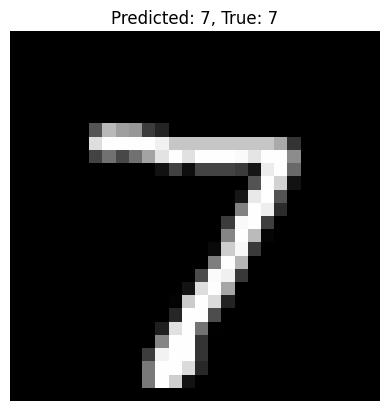

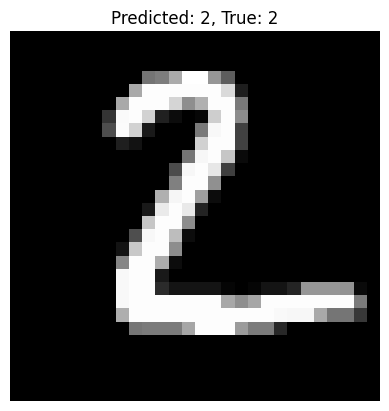

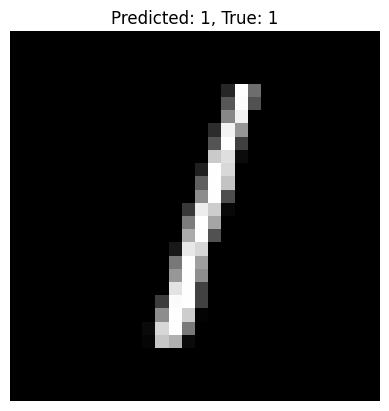

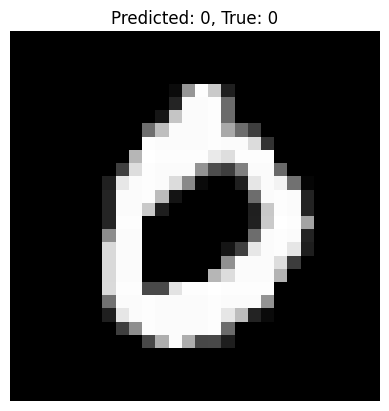

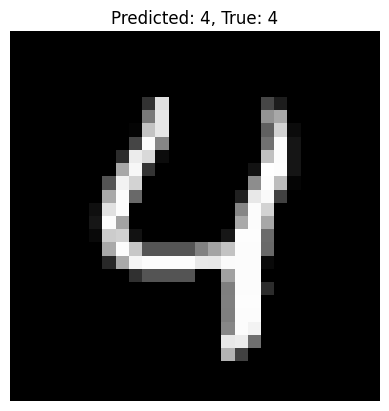

In [ ]:
# Build and train a Convolutional Neural Network (CNN) using TensorFlow 2 to classify handwritten digits from the MNIST dataset.

import tensorflow as tf
import matplotlib.pyplot as plt
from safetensors import tensorflow
from sympy.plotting.backends.matplotlibbackend import matplotlib

# Load MNIST Dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize and reshape input images
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

# Define Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the CNN
model.fit(X_train, y_train, epochs=5, validation_split=0.1, verbose=1)

# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.2f}")

# Visualize predictions
preds = model.predict(X_test[:5])
for i, pred in enumerate(preds):
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title(f"Predicted: {tf.argmax(pred).numpy()}, True: {y_test[i]}")
    plt.axis('off')
    plt.show()

### 17. Image Augmentation with tf.image

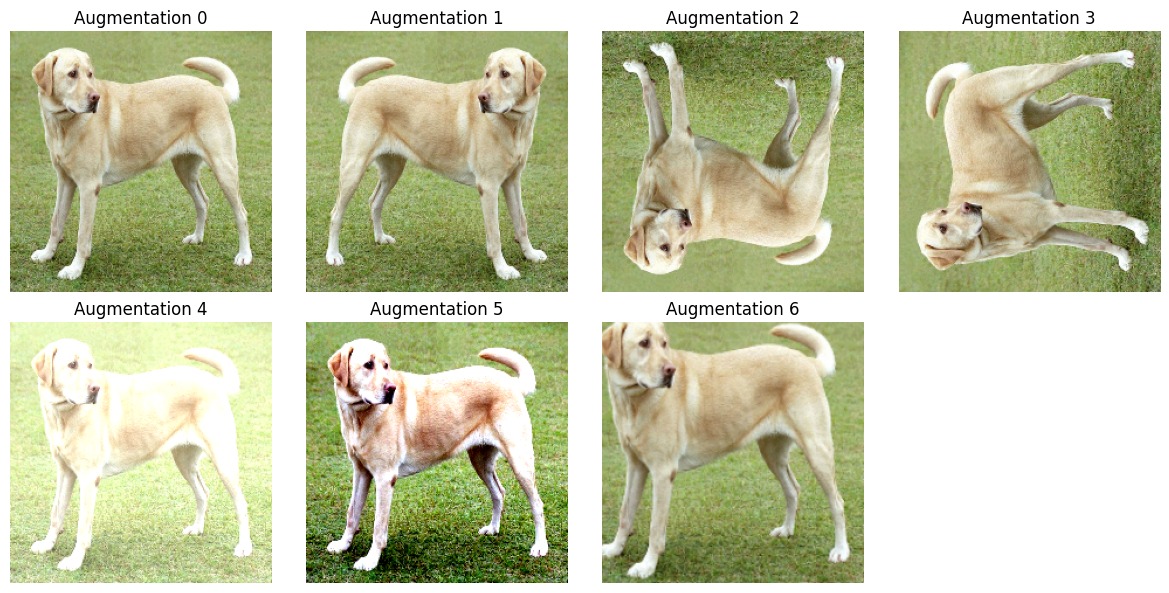

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load and preprocess a sample image
image_path = r"C:\Users\Usha Biratthi\Downloads\antigravity\ML_lib\tensorflow\puppy.jpg"


img_raw = tf.io.read_file(image_path)                          # Read image file as bytes
img = tf.image.decode_jpeg(img_raw, channels=3)                # Decode JPEG image
img = tf.image.resize(img, [224, 224])                         # Resize to 224x224
img = tf.cast(img, tf.float32) / 255.0                         # Normalize to [0, 1]

# Define a list of augmentations using tf.image
augmented_images = [
    img,                                                       # Original image
    tf.image.flip_left_right(img),                             # Horizontal flip
    tf.image.flip_up_down(img),                                # Vertical flip
    tf.image.rot90(img),                                       # Rotate 90 degrees
    tf.image.adjust_brightness(img, 0.3),                      # Brightness adjustment
    tf.image.adjust_contrast(img, 2.0),                        # Contrast enhancement
    tf.image.random_crop(tf.image.resize(img, [256, 256]), size=[224, 224, 3])  # Random crop
]

# Plot all augmented images
plt.figure(figsize=(12, 6))
for i, augmented in enumerate(augmented_images):
    plt.subplot(2, 4, i + 1)
    plt.imshow(tf.clip_by_value(augmented, 0.0, 1.0))          # Clip values to [0, 1] for display
    plt.axis('off')
    plt.title(f"Augmentation {i}")
plt.tight_layout()
plt.show()


### 18. CIFAR-10 Image Classification

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4328 - loss: 1.5501 - val_accuracy: 0.5476 - val_loss: 1.2476
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5807 - loss: 1.1805 - val_accuracy: 0.6062 - val_loss: 1.1266
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6392 - loss: 1.0280 - val_accuracy: 0.6544 - val_loss: 0.9750
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6743 - loss: 0.9338 - val_accuracy: 0.6520 - val_loss: 0.9728
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6995 - loss: 0.8589 - val_accuracy: 0.6662 - val_loss: 0.9443
Test Accuracy: 0.67
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step


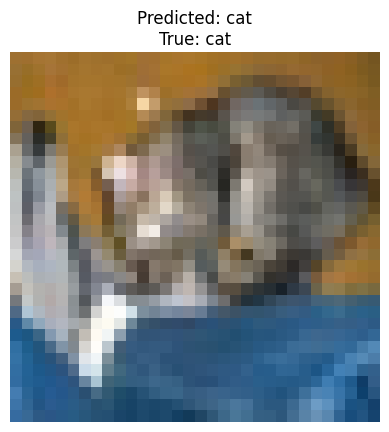

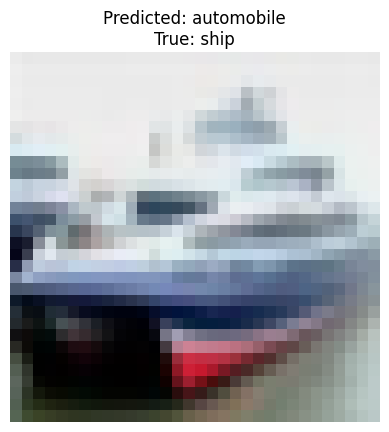

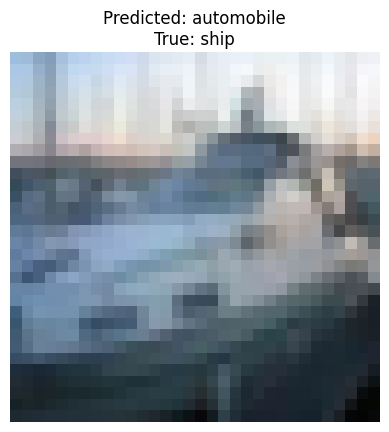

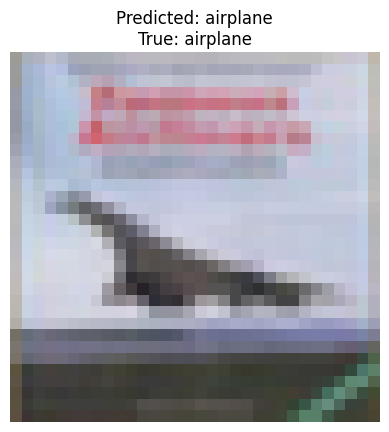

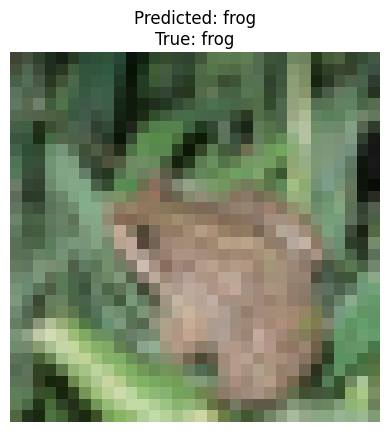

In [1]:
# Train a CNN model on the CIFAR-10 dataset to classify images into 10 categories like airplanes, cats, trucks, etc.

import tensorflow as tf
import matplotlib.pyplot as plt

# Load and normalize CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Define class labels for display
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Build the CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)), # 32 filters
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax') # output for 10 classes
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=5, validation_split=0.1, verbose=1)

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.2f}")

# Predict the model
preds = model.predict(X_test[:5])
for i, pred in enumerate(preds):
    plt.imshow(X_test[i])
    plt.title(f"Predicted: {class_names[tf.argmax(pred)]}\nTrue: {class_names[y_test[i]]}")
    plt.axis('off')
    plt.show()

### 19. Custom CNN for Face Mask Detection

Found 7553 files belonging to 2 classes.
Using 6043 files for training.
Using 1510 files for validation.


C:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 99s 487ms/step - accuracy: 0.6945 - loss: 0.5830 - val_accuracy: 0.7358 - val_loss: 0.5465
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 88s 463ms/step - accuracy: 0.7516 - loss: 0.5196 - val_accuracy: 0.7570 - val_loss: 0.5106
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 134s 421ms/step - accuracy: 0.7615 - loss: 0.5018 - val_accuracy: 0.7523 - val_loss: 0.5135
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 80s 419ms/step - accuracy: 0.7834 - loss: 0.4703 - val_accuracy: 0.8093 - val_loss: 0.4227
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 80s 422ms/step - accuracy: 0.8282 - loss: 0.3959 - val_accuracy: 0.8762 - val_loss: 0.3124
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 70s 367ms/step - accuracy: 0.8703 - loss: 0.3201 - val_accuracy: 0.9053 - val_loss: 0.2500
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 52s 275ms/step - accuracy: 0.8777 - loss: 0.2987 - val_accuracy: 0.9126 - val_loss: 0.2393
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 56s 294ms/step - accuracy: 0.8957 - loss: 

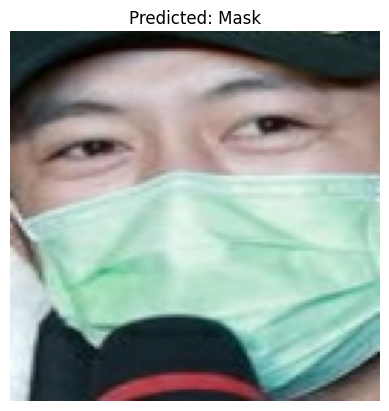

In [1]:
# Train a custom CNN on a face mask dataset to classify whether a person is wearing a mask or not. This uses TensorFlow’s image_dataset_from_directory API for loading data.

import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Dataset link (you'll need to manually download and unzip this in practice)
# Example dataset structure:
# dataset/
# ├── with_mask/
# └── without_mask/
dataset_dir = r"C:\Users\Usha Biratthi\Downloads\antigravity\ML_lib\tensorflow\data"  # Replace with actual path

# Load dataset using image_dataset_from_directory
dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    image_size=(128, 128),                         # Resize all images to 128x128
    batch_size=32,                                 # Batch size
    label_mode='int',                              # Integer labels (0 or 1)
    validation_split=0.2,                          # 80-20 split
    subset="both",                                 # Load both train and val splits
    seed=42
)


train_ds, val_ds = dataset                         # Unpack training and validation sets

# Prefetch for performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Define the custom CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)),   # Normalize pixel values
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')                 # Binary classification
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(train_ds, validation_data=val_ds, epochs=10)

# Example prediction (optional)
for images, labels in val_ds.take(1):                              # Take one batch
    preds = model.predict(images)                                  # Get predictions
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title(f"Predicted: {'Mask' if preds[0] < 0.5 else 'No Mask'}")
    plt.axis('off')
    plt.show()
    break

### 20. Transfer Learning with MobileNet

In [ ]:
# Use MobileNetV2 from TensorFlow Hub as a fixed feature extractor and train a custom classifier on a small dataset (e.g. cats vs dogs).


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version



Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.
Epoch 1/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 114s 534ms/step - accuracy: 0.9563 - loss: 0.1271 - val_accuracy: 0.9694 - val_loss: 0.0809
Epoch 2/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 118s 585ms/step - accuracy: 0.9756 - loss: 0.0669 - val_accuracy: 0.9731 - val_loss: 0.0704
Epoch 3/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 118s 587ms/step - accuracy: 0.9806 - loss: 0.0563 - val_accuracy: 0.9738 - val_loss: 0.0673
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


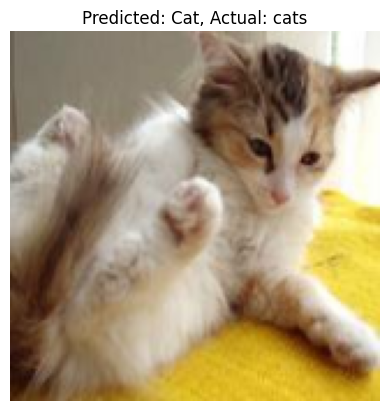

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import os

# Load dataset from local directory
data_dir = r"C:\Users\Usha Biratthi\Downloads\antigravity\ML_lib\tensorflow\data\PetImages"

# Define image parameters
IMG_SIZE = 160
BATCH_SIZE = 32

# Create image dataset from directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# FIX: Save class_names BEFORE caching
class_names = train_ds.class_names

# Preprocess: normalize
def format_image(image, label):
    image = image / 255.0
    return image, label

train_ds = train_ds.map(format_image).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(format_image).prefetch(tf.data.AUTOTUNE)

# Cache datasets for better performance
train_ds = train_ds.cache()
val_ds = val_ds.cache()

# Load MobileNetV2 as feature extractor
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False

# Build the model
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(train_ds, validation_data=val_ds, epochs=3)

# Show prediction on one image
for image, label in val_ds.take(1):
    pred = model.predict(image[:1])
    plt.imshow(image[0].numpy())
    predicted_class = 'Dog' if pred[0][0] > 0.5 else 'Cat'
    actual_class = class_names[label[0].numpy()]
    plt.title(f"Predicted: {predicted_class}, Actual: {actual_class}")
    plt.axis('off')
    plt.show()
    break

Loading dataset from Hugging Face...


Epoch 1/5
    586/Unknown 254s 418ms/step - accuracy: 0.9462 - loss: 0.1258

c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


586/586 ━━━━━━━━━━━━━━━━━━━━ 340s 565ms/step - accuracy: 0.9671 - loss: 0.0874 - val_accuracy: 0.9742 - val_loss: 0.0675
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 328s 559ms/step - accuracy: 0.9782 - loss: 0.0573 - val_accuracy: 0.9737 - val_loss: 0.0638
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 374s 638ms/step - accuracy: 0.9826 - loss: 0.0461 - val_accuracy: 0.9789 - val_loss: 0.0611
Epoch 4/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 376s 641ms/step - accuracy: 0.9868 - loss: 0.0365 - val_accuracy: 0.9761 - val_loss: 0.0638
Epoch 5/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 1006s 2s/step - accuracy: 0.9901 - loss: 0.0292 - val_accuracy: 0.9784 - val_loss: 0.0661


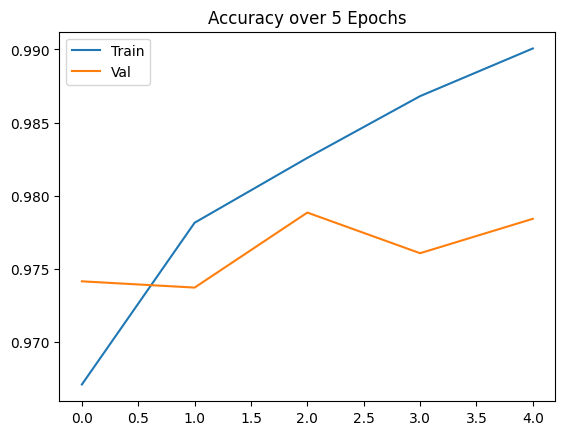

Model saved successfully.


In [1]:
import tensorflow as tf
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

# 1. Configuration
IMG_SIZE = 160
BATCH_SIZE = 32
EPOCHS = 5

# 2. Load and Prepare Dataset
print("Loading dataset from Hugging Face...")
ds = load_dataset("microsoft/cats_vs_dogs", split='train')
ds = ds.train_test_split(test_size=0.2, seed=123)

def preprocess(example):
    image = example['image'].resize((IMG_SIZE, IMG_SIZE)).convert('RGB')
    return tf.convert_to_tensor(np.array(image), dtype=tf.float32) / 255.0, example['labels']

# 3. Create Optimized TensorFlow Pipeline
def prepare_ds(hf_ds):
    # Using from_generator is standard for HF compatibility
    ds = tf.data.Dataset.from_generator(
        lambda: (preprocess(ex) for ex in hf_ds),
        output_signature=(tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
                          tf.TensorSpec(shape=(), dtype=tf.int64))
    )
    return ds.shuffle(1000).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

train_ds = prepare_ds(ds['train'])
val_ds = prepare_ds(ds['test'])

# 4. Build Model (MobileNetV2 Transfer Learning)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# 6. Quick Visualization
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(acc, label='Train')
plt.plot(val_acc, label='Val')
plt.legend()
plt.title('Accuracy over 5 Epochs')
plt.show()

# 7. Save
model.save('cat_dog_model.keras')
print("Model saved successfully.")

### 21. Fine-Tune InceptionV3

Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.
Epoch 1/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 838s 4s/step - accuracy: 0.9764 - loss: 0.0664 - val_accuracy: 0.9931 - val_loss: 0.0147
Epoch 2/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 913s 5s/step - accuracy: 0.9925 - loss: 0.0245 - val_accuracy: 0.9950 - val_loss: 0.0113
Epoch 3/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 1008s 5s/step - accuracy: 0.9917 - loss: 0.0236 - val_accuracy: 0.9981 - val_loss: 0.0083
Epoch 1/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 1128s 5s/step - accuracy: 0.9820 - loss: 0.0562 - val_accuracy: 0.9931 - val_loss: 0.0117
Epoch 2/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 764s 4s/step - accuracy: 0.9938 - loss: 0.0180 - val_accuracy: 0.9950 - val_loss: 0.0115
Epoch 3/3
201/201 ━━━━━━━━━━━━━━━━━━━━ 784s 4s/step - accuracy: 0.9953 - loss: 0.0149 - val_accuracy: 0.9944 - val_loss: 0.0116
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


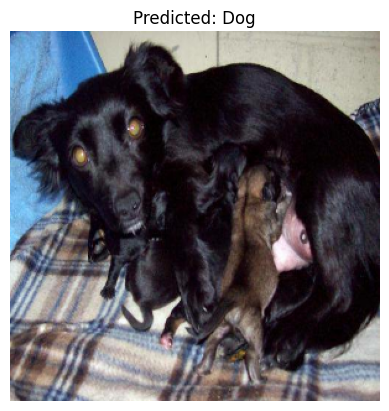

In [1]:
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# # 1. Configuration
data_dir = r"C:\Users\Usha Biratthi\Downloads\antigravity\ML_lib\tensorflow\data\PetImages"
IMG_SIZE = 299 # InceptionV3 standard size
BATCH_SIZE = 32

# 2. Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)

# 3. Corrected Preprocessing (Removed redundant batching)
def preprocess(image, label):
    image = preprocess_input(image) # Normalizes to [-1, 1] as required by InceptionV3
    return image, label

train_ds = train_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
 
# 4. Load InceptionV3
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False 
 
# 5. Build model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
 
# 6. Train initial frozen model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=3)
 
# 7. Fine-tuning
base_model.trainable = True
# Freeze all layers except the last 50
for layer in base_model.layers[:-50]:
    layer.trainable = False
 
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=3)
 
# 8. Prediction
for image, label in val_ds.take(1):
    pred = model.predict(image[:1])
    # Denormalize for display (InceptionV3 moves data to [-1, 1])
    display_img = (image[0] + 1) * 127.5
    plt.imshow(tf.cast(display_img, tf.uint8))
    plt.title(f"Predicted: {'Dog' if pred[0][0] > 0.5 else 'Cat'}")
    plt.axis('off')
    plt.show()
    break

Loading dataset from Hugging Face...
Epoch 1/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 188s 288ms/step - accuracy: 0.9872 - loss: 0.0423 - val_accuracy: 0.9955 - val_loss: 0.0188
Epoch 2/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 165s 272ms/step - accuracy: 0.9921 - loss: 0.0262 - val_accuracy: 0.9951 - val_loss: 0.0189
Epoch 3/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 201s 335ms/step - accuracy: 0.9933 - loss: 0.0215 - val_accuracy: 0.9949 - val_loss: 0.0194
Epoch 1/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 213s 316ms/step - accuracy: 0.9864 - loss: 0.0401 - val_accuracy: 0.9942 - val_loss: 0.0212
Epoch 2/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 169s 279ms/step - accuracy: 0.9957 - loss: 0.0146 - val_accuracy: 0.9947 - val_loss: 0.0208
Epoch 3/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 166s 273ms/step - accuracy: 0.9965 - loss: 0.0105 - val_accuracy: 0.9951 - val_loss: 0.0210
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


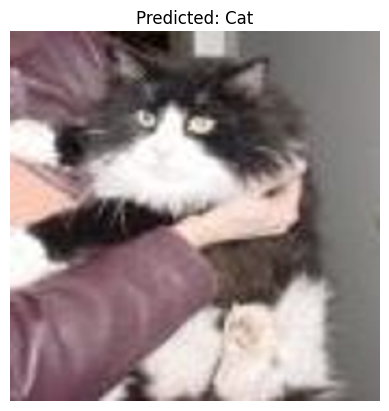

In [2]:
import tensorflow as tf
import numpy as np
from datasets import load_dataset
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Configuration
IMG_SIZE = 299 
BATCH_SIZE = 32
EPOCHS_INITIAL = 3
EPOCHS_FINETUNE = 3

# 2. Load dataset from Hugging Face
print("Loading dataset from Hugging Face...")
ds = load_dataset("microsoft/cats_vs_dogs", split='train')
ds_split = ds.train_test_split(test_size=0.2, seed=123)

def preprocess_hf(example):
    # Convert HF PIL Image to RGB and resize
    image = example['image'].convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    image = np.array(image, dtype=np.float32)
    # Apply InceptionV3 preprocessing: scales to [-1, 1]
    image = preprocess_input(image)
    return image, example['labels']

# 3. Create TensorFlow Dataset from Generator
def tf_generator(hf_dataset):
    for example in hf_dataset:
        yield preprocess_hf(example)

output_signature = (
    tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(), dtype=tf.int64)
)

train_ds = tf.data.Dataset.from_generator(
    lambda: tf_generator(ds_split['train']), output_signature=output_signature
).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: tf_generator(ds_split['test']), output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 4. Build Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# 5. Train initial frozen model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_INITIAL)

# 6. Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE)

# 7. Prediction
for image, label in val_ds.take(1):
    pred = model.predict(image[:1])
    # Denormalize for display (InceptionV3 moves data to [-1, 1])
    display_img = (image[0] + 1) * 127.5
    plt.imshow(tf.cast(display_img, tf.uint8))
    plt.title(f"Predicted: {'Dog' if pred[0][0] > 0.5 else 'Cat'}")
    plt.axis('off')
    plt.show()
    break

### 22. Object Detection with TF Hub SSD

In [2]:
pip install requests io PTL

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement io (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for io


Loading model from TensorFlow Hub...


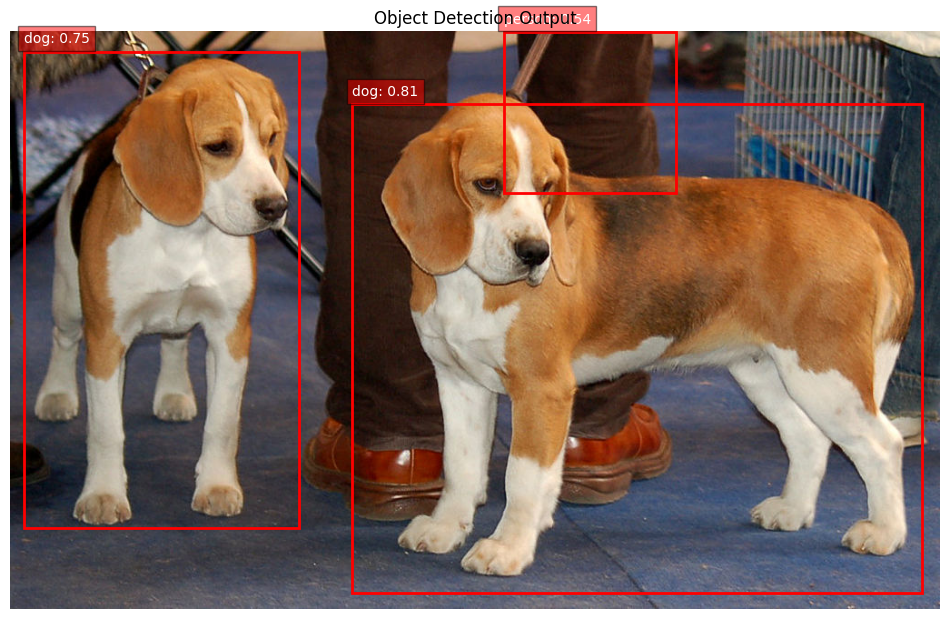

In [ ]:
# Use a pretrained SSD MobileNet model from TensorFlow Hub to detect objects in an image, and draw bounding boxes and labels.
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
from PIL import Image

# 1. Load the Model
print("Loading model from TensorFlow Hub...")
detector = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")

# 2. Define Full COCO Labels
# This list accounts for the specific indices returned by the COCO-trained model
labels = [
    "background", "person", "bicycle", "car", "motorcycle", "airplane", 
    "bus", "train", "truck", "boat", "traffic light", "fire hydrant", 
    "unknown", "stop sign", "parking meter", "bench", "bird", "cat", 
    "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", 
    "unknown", "backpack", "umbrella", "unknown", "unknown", "handbag", 
    "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", 
    "kite", "baseball bat", "baseball glove", "skateboard", "surfboard", 
    "tennis racket", "bottle", "unknown", "wine glass", "cup", "fork", 
    "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", 
    "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", 
    "couch", "potted plant", "bed", "unknown", "dining table", "unknown", 
    "unknown", "toilet", "unknown", "tv", "laptop", "mouse", "remote", 
    "keyboard", "cell phone", "microwave", "oven", "toaster", "sink", 
    "refrigerator", "unknown", "book", "clock", "vase", "scissors", 
    "teddy bear", "hair drier", "toothbrush"
]

# 3. Load and Preprocess Image
image_url = "https://raw.githubusercontent.com/tensorflow/models/master/research/object_detection/test_images/image1.jpg"

headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(image_url, headers=headers)
response.raise_for_status()

# Convert to PIL Image -> NumPy Array
img = Image.open(io.BytesIO(response.content)).convert('RGB')
img_array = np.array(img)

# Convert to uint8 and add batch dimension [1, H, W, 3]
img_tensor = tf.convert_to_tensor(img_array, dtype=tf.uint8)
img_tensor = img_tensor[tf.newaxis, ...]

# 4. Inference
result = detector(img_tensor)

# 5. Extract and Post-process
boxes = result['detection_boxes'][0].numpy()
classes = result['detection_classes'][0].numpy().astype(int)
scores = result['detection_scores'][0].numpy()

# 6. Visualization
plt.figure(figsize=(12, 8))
plt.imshow(img_array)
ax = plt.gca()

height, width, _ = img_array.shape

for i in range(len(scores)):
    if scores[i] < 0.5:
        continue
        
    ymin, xmin, ymax, xmax = boxes[i]
    left, right, top, bottom = xmin * width, xmax * width, ymin * height, ymax * height
    
    # Draw Bounding Box
    rect = plt.Rectangle((left, top), right - left, bottom - top, 
                         edgecolor='red', facecolor='none', linewidth=2)
    ax.add_patch(rect)
    
    # Labeling
    class_id = classes[i]
    # Ensure index is within range of our list
    label_text = labels[class_id] if class_id < len(labels) else "unknown"
    
    ax.text(left, top - 10, f"{label_text}: {scores[i]:.2f}", 
            color='white', fontsize=10, bbox=dict(facecolor='red', alpha=0.5))

plt.axis("off")
plt.title("Object Detection Output")
plt.show()

### 23. Real-Time Object Detection with Webcam

In [12]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Use TensorFlow Hub’s SSD MobileNet model to perform object detection on live webcam feed using OpenCV and draw bounding boxes with class labels.

import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np

# 1. Load the Model
print("Loading model from TensorFlow Hub...")
detector = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")

# 2. Load COCO labels via Keras utils
# Using a reliable raw text file from GitHub to avoid 403 Forbidden errors
lables_path = tf.keras.utils.get_file(
    'mscoco_label_map.txt',
    'https://raw.githubusercontent.com/amikelive/coco-labels/master/coco-labels-2014_2017.txt'
)

with open(lables_path, 'r') as f:
    labels = [line.strip() for line in f.readlines()]

# Important: The SSD MobileNet model expects "background" at index 0.
# The text file doesn't have it, so we manually insert it.
labels.insert(0, "background")

# 3. Start webcam feed
cap = cv2.VideoCapture(0)

print("Starting detection. Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # 4. Preprocess the frame
    # Convert BGR (OpenCV default) to RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Convert to Tensor (uint8) and add batch dimension [1, H, W, 3]
    # The model handles normalization internally, so we leave it as 0-255
    input_tensor = tf.convert_to_tensor(rgb_frame, dtype=tf.uint8)[tf.newaxis, ...]

    # 5. Run detection
    detections = detector(input_tensor)
    
    # 6. Extract results (remove batch dimension [0])
    boxes = detections['detection_boxes'][0].numpy()
    classes = detections['detection_classes'][0].numpy().astype(int)
    scores = detections['detection_scores'][0].numpy()

    # 7. Visualization
    h, w, _ = frame.shape
    for i in range(len(scores)):
        # Only visualize detections with confidence > 50%
        if scores[i] < 0.5:
            continue
        
        # Unpack normalized coordinates [ymin, xmin, ymax, xmax]
        ymin, xmin, ymax, xmax = boxes[i]
        
        # Scale to actual pixel coordinates
        left, top = int(xmin * w), int(ymin * h)
        right, bottom = int(xmax * w), int(ymax * h)
        
        # Draw rectangle
        cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
        
        # Add label
        class_id = classes[i]
        # Safety check: ensure class_id is within our labels list
        label_text = labels[class_id] if class_id < len(labels) else "unknown"
        
        cv2.putText(frame, f"{label_text} {scores[i]:.2f}", (left, top - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Show frame
    cv2.imshow('Real-Time Object Detection', frame)

    # Press 'q' to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Loading model from TensorFlow Hub...
620/620 ━━━━━━━━━━━━━━━━━━━━ 0s 10us/step
Starting detection. Press 'q' to quit.


In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np

# 1. Load the Model
print("Loading model from TensorFlow Hub...")
detector = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")

# 2. Define Full COCO Labels
from labels import labels

# 3. Start webcam feed
cap = cv2.VideoCapture(0)

print("Starting detection. Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess: OpenCV uses BGR, convert to RGB
    # We keep it as uint8 (0-255) as the model handles normalization internally
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    input_tensor = tf.convert_to_tensor(rgb_frame, dtype=tf.uint8)[tf.newaxis, ...]

    # Run detection
    detections = detector(input_tensor)
    
    # Extract results
    # The output is a dictionary, we pull out the arrays
    boxes = detections['detection_boxes'][0].numpy()
    classes = detections['detection_classes'][0].numpy().astype(int)
    scores = detections['detection_scores'][0].numpy()

    # Draw detections
    h, w, _ = frame.shape
    for i in range(len(scores)):
        if scores[i] < 0.5:
            continue
        
        # Get coordinates
        ymin, xmin, ymax, xmax = boxes[i]
        left, top = int(xmin * w), int(ymin * h)
        right, bottom = int(xmax * w), int(ymax * h)
        
        # Draw rectangle
        cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
        
        # Add label
        class_id = classes[i]
        label_text = labels[class_id] if class_id < len(labels) else "unknown"
        cv2.putText(frame, f"{label_text} {scores[i]:.2f}", (left, top - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Show frame
    cv2.imshow('Real-Time Object Detection', frame)

    # Press 'q' to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Loading model from TensorFlow Hub...
Starting detection. Press 'q' to quit.


### 24. Semantic Segmentation with DeepLabV3+

In [13]:
pip install keras-cv tensorflow matplotlib requests

Loading ResNet50V2 Backbone...
Loading DeepLabV3+ model with Pascal VOC weights...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


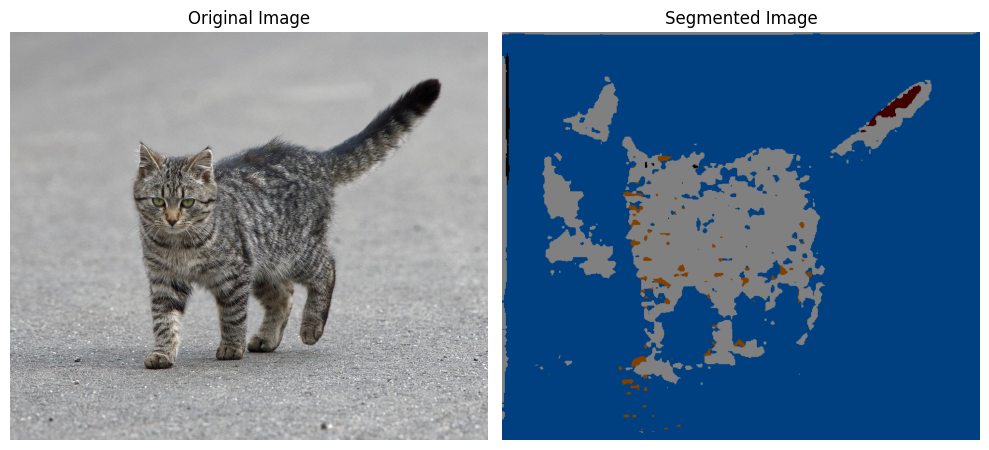

In [33]:
import tensorflow as tf
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

# 1. Instantiate the Backbone
# Using ResNet50V2 for robust feature extraction in the encoder
print("Loading ResNet50V2 Backbone...")
backbone = keras_cv.models.ResNet50V2Backbone(
    include_rescaling=True, 
    weights="imagenet"
)

# 2. Load the DeepLabV3+ model
# DeepLabV3+ architecture for precise semantic segmentation
print("Loading DeepLabV3+ model with Pascal VOC weights...")
model = keras_cv.models.DeepLabV3Plus(
    num_classes=21, 
    backbone=backbone,
    weights="pascal_voc"
)

# 3. Load and preprocess the input image
# Using the stable URL provided
image_url = "https://raw.githubusercontent.com/DeGirum/PySDKExamples/main/images/Cat.jpg"

response = requests.get(image_url)
response.raise_for_status()

img = np.array(Image.open(BytesIO(response.content)))

# Store original size for scaling the mask back up
original_size = img.shape[:2]

# Preprocessing: Resize and normalize
img_resized = tf.image.resize(img, [512, 512])
img_tensor = tf.expand_dims(tf.cast(img_resized, tf.float32) / 255.0, 0)

# 4. Run the model
result = model.predict(img_tensor)
segmentation_map = np.argmax(result[0], axis=-1)

# 5. Define and apply color map (Pascal VOC)
def create_pascal_label_colormap():
    colormap = np.zeros((256, 3), dtype=int)
    for i in range(256):
        r, g, b = 0, 0, 0
        c = i
        for j in range(8):
            r |= (c & 1) << (7 - j)
            g |= ((c >> 1) & 1) << (7 - j)
            b |= ((c >> 2) & 1) << (7 - j)
            c >>= 3
        colormap[i] = [r, g, b]
    return colormap

colormap = create_pascal_label_colormap()
segmentation_color = colormap[segmentation_map]

# Resize prediction mask back to original image size
# Result of this operation is a tf.Tensor
segmentation_color = tf.image.resize(segmentation_color, original_size, method='nearest')

# 6. Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
# FIX: Convert the tensor to numpy array before using .astype()
plt.imshow(segmentation_color.numpy().astype(np.uint8))
plt.title("Segmented Image")
plt.axis('off')
plt.tight_layout()
plt.show()

Loading ResNet50V2 Backbone...


Loading DeepLabV3+ model with Pascal VOC weights...
Original image size: 424 x 640
Running segmentation prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Segmentation result saved to: segmentation_result.png


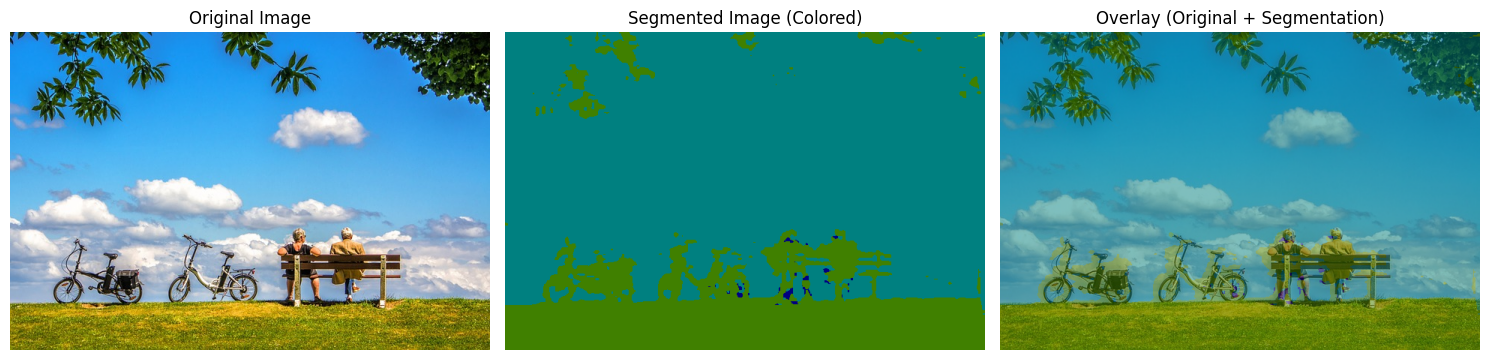


DETECTED OBJECT CLASSES:
  ✓ boat
  ✓ bus
  ✓ cow
  ✓ train


In [32]:
import tensorflow as tf
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO



# ============================================================
# 1. Instantiate the Backbone
# ============================================================
print("Loading ResNet50V2 Backbone...")
backbone = keras_cv.models.ResNet50V2Backbone(
    include_rescaling=True, 
    weights="imagenet"
)



# ============================================================
# 2. Load the DeepLabV3+ model
# ============================================================
print("Loading DeepLabV3+ model with Pascal VOC weights...")
model = keras_cv.models.DeepLabV3Plus(
    num_classes=21, 
    backbone=backbone,
    weights="pascal_voc"
)



# ============================================================
# 3. Load and preprocess the input image
# Using GitHub Raw URL (works reliably)
# ============================================================
print("Downloading image from GitHub...")
image_url = "https://raw.githubusercontent.com/DeGirum/PySDKExamples/main/images/bikes.jpg"


try:
    response = requests.get(image_url)
    response.raise_for_status()
    img = np.array(Image.open(BytesIO(response.content)))
except Exception as e:
    print(f"Error downloading image: {e}")
    print("Falling back to creating a test image...")
    img = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)


# Store original size for scaling the mask back up
original_size = img.shape[:2]
print(f"Original image size: {original_size[0]} x {original_size[1]}")



# Preprocessing: Resize and normalize
img_resized = tf.image.resize(img, [512, 512])
img_tensor = tf.expand_dims(tf.cast(img_resized, tf.float32) / 255.0, 0)



# ============================================================
# 4. Run the model
# ============================================================
print("Running segmentation prediction...")
result = model.predict(img_tensor)
segmentation_map = np.argmax(result[0], axis=-1)



# ============================================================
# 5. Define and apply color map (Pascal VOC)
# ============================================================
def create_pascal_label_colormap():
    """Create Pascal VOC colormap for 256 classes."""
    colormap = np.zeros((256, 3), dtype=int)
    for i in range(256):
        r, g, b = 0, 0, 0
        c = i
        for j in range(8):
            r |= (c & 1) << (7 - j)
            g |= ((c >> 1) & 1) << (7 - j)
            b |= ((c >> 2) & 1) << (7 - j)
            c >>= 3
        colormap[i] = [r, g, b]
    return colormap


colormap = create_pascal_label_colormap()
segmentation_color = colormap[segmentation_map]


# Resize prediction mask back to original image size
segmentation_color_tf = tf.image.resize(
    tf.cast(segmentation_color, tf.float32), 
    original_size, 
    method='nearest'
)

# FIX: Convert TensorFlow tensor to NumPy array
segmentation_color = tf.numpy_function(
    lambda x: tf.image.resize(x, original_size, method='nearest').numpy(),
    [segmentation_color],
    tf.uint8
)
segmentation_color = segmentation_color.numpy()



# ============================================================
# 6. Plot the results
# ============================================================
plt.figure(figsize=(15, 6))


plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')


plt.subplot(1, 3, 2)
plt.imshow(segmentation_color.astype(np.uint8))
plt.title("Segmented Image (Colored)")
plt.axis('off')


# Create overlay for better visualization
overlay = (img * 0.5 + segmentation_color.astype(np.float32) * 0.5).astype(np.uint8)
plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay (Original + Segmentation)")
plt.axis('off')


plt.tight_layout()
plt.savefig('segmentation_result.png', dpi=150, bbox_inches='tight')
print("\nSegmentation result saved to: segmentation_result.png")
plt.show()



# ============================================================
# 7. Print detected classes
# ============================================================
class_names = [
    "background", "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable", "dog", "horse",
    "motorbike", "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]


unique_classes = np.unique(segmentation_map)
detected_classes = [class_names[c] for c in unique_classes if c < 21 and c != 0]


print("\n" + "=" * 50)
print("DETECTED OBJECT CLASSES:")
print("=" * 50)
if detected_classes:
    for cls in detected_classes:
        print(f"  ✓ {cls}")
else:
    print("  No object classes detected (only background)")
print("=" * 50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


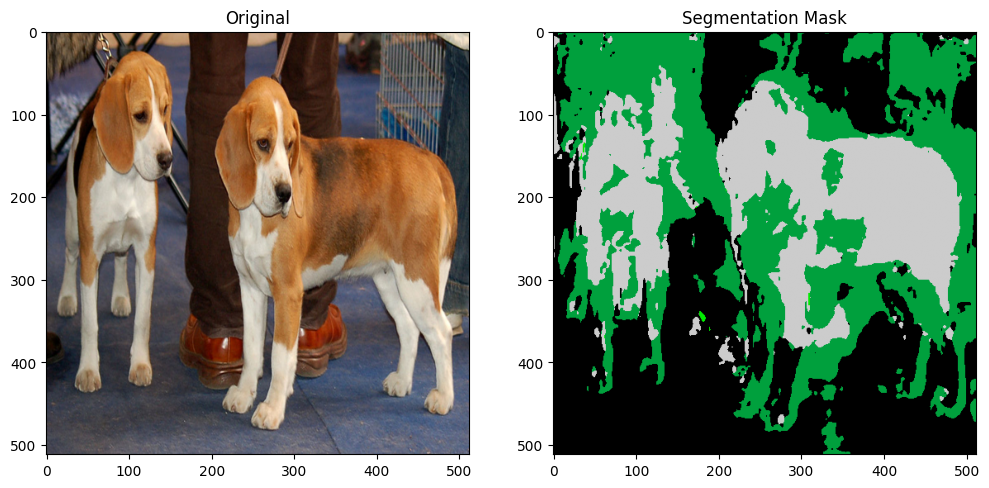

In [9]:
# pip install keras-cv tensorflow
# pip install segmentation-models

import keras_cv
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
from PIL import Image

# 1. Load a modern Segmentation Model
# We specify the backbone and the number of classes.
# Specifying weights="pascal_voc" ensures the model works out-of-the-box.
backbone = keras_cv.models.ResNet50Backbone(
    weights="imagenet",
    include_rescaling=False
)

model = keras_cv.models.segmentation.DeepLabV3Plus(
    num_classes=21, # Corrected parameter name
    backbone=backbone,
    input_shape=(512, 512, 3),
    weights="pascal_voc" # Load pre-trained weights for semantic segmentation
)

# 2. Preprocess the image
def preprocess(image_url):
    response = requests.get(image_url, headers={'User-Agent': 'Mozilla/5.0'})
    response.raise_for_status()
    img = Image.open(io.BytesIO(response.content)).convert('RGB')
    img = img.resize((512, 512))
    img_array = np.array(img) / 255.0
    return np.array(img), np.expand_dims(img_array, axis=0)

# 3. Execution
url = "https://raw.githubusercontent.com/tensorflow/models/master/research/object_detection/test_images/image1.jpg"
original_img, input_tensor = preprocess(url)

# Perform inference
predictions = model.predict(input_tensor)

# Get the mask (argmax over the classes axis)
# Predictions shape is [1, 512, 512, 21]
seg_map = np.argmax(predictions[0], axis=-1)

# 4. Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(original_img); plt.title("Original")
plt.subplot(1, 2, 2); plt.imshow(seg_map, cmap='nipy_spectral'); plt.title("Segmentation Mask")
plt.show()

### 25. OCR with CNN + CTC Loss (Handwritten Text Recognition)

In [1]:
import tensorflow as tf
import numpy as np

# Simulate data (normally you'd load from real OCR dataset like IAM or SynthText)
# Example: batch of 16 grayscale images of shape (100, 32) representing word images
batch_size = 16
img_width, img_height = 100, 32
num_classes = 26 + 1 + 1  # a-z + blank + padding/CTC special
X_data = np.random.rand(batch_size, img_height, img_width, 1).astype(np.float32)
y_data = np.random.randint(1, 27, size=(batch_size, 10))  # Random 10-letter sequences
 
# Input lengths (how many time steps per image) after downsampling (e.g., 1/4)
input_lengths = np.full((batch_size, 1), img_width // 4, dtype=np.int32)
label_lengths = np.full((batch_size, 1), 10, dtype=np.int32)
 
# Define a basic CNN + CTC model
input_img = tf.keras.Input(shape=(img_height, img_width, 1), name='input_image')
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
 
# Reshape for RNN
new_shape = (img_width // 4, (img_height // 4) * 64)
x = tf.keras.layers.Reshape(target_shape=new_shape)(x)
 
# Bidirectional LSTM for sequence modeling
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True))(x)
x = tf.keras.layers.Dense(num_classes, activation='softmax')(x)  # Predict char at each timestep
 
# Define CTC loss layer
labels = tf.keras.Input(shape=(None,), dtype='int32', name='labels')
input_len = tf.keras.Input(shape=(1,), dtype='int32', name='input_length')
label_len = tf.keras.Input(shape=(1,), dtype='int32', name='label_length')
 
def ctc_lambda_func(args):
    y_pred, labels, input_len, label_len = args
    return tf.keras.backend.ctc_batch_cost(labels, y_pred, input_len, label_len)
 
loss_out = tf.keras.layers.Lambda(ctc_lambda_func, output_shape=(1,), name='ctc')(
    [x, labels, input_len, label_len])
 
# Compile model with dummy loss (loss computed inside Lambda layer)
model = tf.keras.Model(inputs=[input_img, labels, input_len, label_len], outputs=loss_out)
model.compile(optimizer='adam', loss={'ctc': lambda y_true, y_pred: y_pred})
 
# Train with synthetic data
model.fit(
    x={'input_image': X_data, 'labels': y_data, 'input_length': input_lengths, 'label_length': label_lengths},
    y=np.zeros((batch_size, 1)),  # Dummy target for CTC
    epochs=1
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step - loss: 61.4990


### 26.Image Colorization using U-Net

In [1]:
pip install skimage

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [3 lines of output]
      
      *** Please install the `scikit-image` package (instead of `skimage`) ***
      
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Failed to build 'skimage' when getting requirements to build wheel


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step


C:\Users\Usha Biratthi\AppData\Local\Temp\ipykernel_17552\116796458.py:40: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 41 negative Z values that have been clipped to zero
  rgb_out = lab2rgb(lab_output)                                     # Convert LAB back to RGB


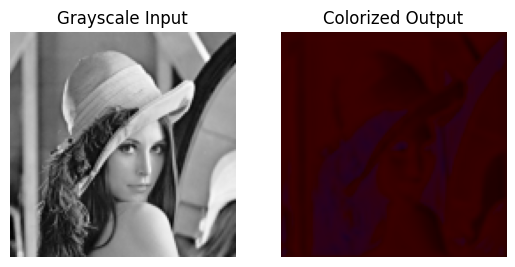

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb
from skimage.io import imread
from skimage.transform import resize

# Load and preprocess image from GitHub raw link
img_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
rgb = imread(img_url) / 255.0   # Load and normalize image
rgb = resize(rgb, (128, 128))   # Resize to 128x128

# Convert to LAB color space
lab = rgb2lab(rgb)
X_l = lab[..., 0:1] / 100.0     # Normalize L channel to [0, 1]
y_ab = lab[..., 1:] / 128.0     # Normalize ab channels to [-1, 1]

# Add batch dimension
X_l = X_l[np.newaxis, ...]
y_ab = y_ab[np.newaxis, ...]

# Define simplified U-Net model
inputs = tf.keras.Input(shape=(128, 128, 1))
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D()(x)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
outputs = tf.keras.layers.Conv2D(2, 3, activation='tanh', padding='same')(x)  # Predict ab channels

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')

# Train on single image (demo only)
model.fit(X_l, y_ab, epochs=100, verbose=0)

# Predict ab channels and reconstruct LAB image
pred_ab = model.predict(X_l)[0]
lab_output = np.concatenate([X_l[0], pred_ab * 128.0], axis=-1)   # Denormalize ab and combine
rgb_out = lab2rgb(lab_output)                                     # Convert LAB back to RGB

# Plot input and output
plt.subplot(1, 2, 1)
plt.imshow(X_l[0].squeeze(), cmap='gray')
plt.title("Grayscale Input")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_out)
plt.title("Colorized Output")
plt.axis('off')
plt.show()
